# Dataset Loading
---
source: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

In [1]:
import kagglehub
path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')
print('Path to dataset files:', path)

C:\Users\OWM\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 2.29G/2.29G [20:29<00:00, 2.00MB/s]

Extracting files...


Path to dataset files: C:\Users\OWM\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


## Generating Pre-split Dataset CSV
Create a csv to view the pre-split dataset (merged folders). Splitting is done later programmatically.

In [2]:
import os
import hashlib
import pandas as pd

CLASSES = ['NORMAL', 'PNEUMONIA']
CSV_PATH= './dataset.csv'

# Path to the dataset
root = os.path.join(path, 'chest_xray')

# Function to get file hash (used for removing duplicate images)
def get_file_hash(file_path:str):
    hash_md5 = hashlib.md5()
    with open(file_path, 'rb') as f:
        for chunk in iter(lambda: f.read(4096), b''):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

if not os.path.exists(CSV_PATH):
    # For each class, collect unique images from train, val, test
    img_paths  = []
    img_labels = []
    for cls in CLASSES:
        hashes = set()
        for split in ['train', 'val', 'test']:
            folder = os.path.join(root, split, cls)
            if os.path.exists(folder):
                for fn in os.listdir(folder):
                    fullpath= os.path.join(folder, fn)
                    hash = get_file_hash(fullpath)
                    if hash not in hashes:
                        hashes.add(hash)
                        img_paths.append(fullpath)
                        img_labels.append(cls)
                    else:
                        print(f'Skipped: {fn}')

Skipped: NORMAL2-IM-0587-0001-0002.jpeg
Skipped: NORMAL2-IM-0096-0001.jpeg
Skipped: NORMAL2-IM-0173-0001-0002.jpeg
Skipped: NORMAL2-IM-0246-0001-0002.jpeg
Skipped: person1159_virus_1945.jpeg
Skipped: person124_virus_247.jpeg
Skipped: person1261_virus_2148.jpeg
Skipped: person1312_bacteria_3318.jpeg
Skipped: person1343_bacteria_3414.jpeg
Skipped: person1349_bacteria_3437.jpeg
Skipped: person1372_bacteria_3502.jpeg
Skipped: person1372_bacteria_3503.jpeg
Skipped: person1430_bacteria_3696.jpeg
Skipped: person1481_bacteria_3863.jpeg
Skipped: person1481_bacteria_3865.jpeg
Skipped: person1481_bacteria_3867.jpeg
Skipped: person1496_bacteria_3910.jpeg
Skipped: person1619_bacteria_4268.jpeg
Skipped: person1628_bacteria_4298.jpeg
Skipped: person162_virus_322.jpeg
Skipped: person258_bacteria_1208.jpeg
Skipped: person258_bacteria_1209.jpeg
Skipped: person264_bacteria_1231.jpeg
Skipped: person266_bacteria_1238.jpeg
Skipped: person30_bacteria_157.jpeg
Skipped: person357_virus_735.jpeg
Skipped: person

Save CSV (This is how we view the dataset)

In [3]:
df= pd.DataFrame({'images': img_paths, 'labels': img_labels})
df.to_csv(CSV_PATH, index=False)

### Some Class Balance Analysis

In [6]:
print(f'Dataset outline created: {CSV_PATH}')
counts= df['labels'].value_counts()
for cls in df['labels'].unique():
    print(f'{cls+":": <10} {counts[cls]} images')
print(f'TOTAL {len(df["labels"])} images')

Dataset outline created: ./dataset.csv
NORMAL:    1579 images
PNEUMONIA: 4245 images
TOTAL 5824 images


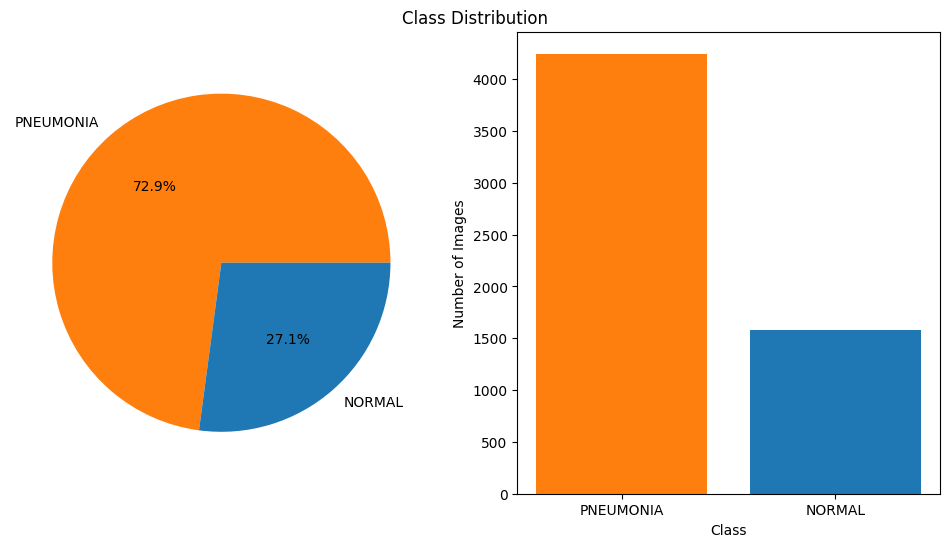

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.title('Class Distribution')
plt.axis('off')
plt.subplot(1, 2, 1); plt.pie(counts, labels=counts.keys(), colors=('C1', 'C0'), autopct='%.1f%%')
plt.subplot(1, 2, 2); plt.bar(counts.keys(), height=counts, color =('C1', 'C0'))
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()